In [ ]:
import pandas as pd
import random
import matplotlib.pyplot as plt

In [ ]:
NUM_RECORDS = 1000

data = []

for i in range(1, NUM_RECORDS + 1):
    record = {
        "transaction_id": f"T{i:04}",
        "amount": random.randint(100, 20000),
        "transactions_per_day": random.randint(1, 15),
        "location_risk": random.choice(["Low", "Medium", "High"])
    }
    data.append(record)

df = pd.DataFrame(data)

df.to_csv("intelliguard_dataset.csv", index=False)

df.head()

,transaction_id,amount,transactions_per_day,location_risk
0,T0001,13945,3,High
1,T0002,7753,13,High
2,T0003,2601,5,Low
3,T0004,17866,9,Medium
4,T0005,18271,6,Medium


In [ ]:
data = pd.read_csv("intelliguard_dataset.csv")

data.head()

,transaction_id,amount,transactions_per_day,location_risk
0,T0001,13945,3,High
1,T0002,7753,13,High
2,T0003,2601,5,Low
3,T0004,17866,9,Medium
4,T0005,18271,6,Medium


In [ ]:
def calculate_score(row):
    score = 0

    # Amount
    if row["amount"] > 10000:
        score += 40
    elif row["amount"] > 5000:
        score += 25
    else:
        score += 10

    # Transaction frequency
    if row["transactions_per_day"] > 10:
        score += 30
    elif row["transactions_per_day"] > 5:
        score += 20
    else:
        score += 10

    # Location risk
    if row["location_risk"] == "High":
        score += 20
    elif row["location_risk"] == "Medium":
        score += 10
    else:
        score += 5

    return score

In [ ]:
data["risk_score"] = data.apply(calculate_score, axis=1)

data.head()

,transaction_id,amount,transactions_per_day,location_risk,risk_score
0,T0001,13945,3,High,70
1,T0002,7753,13,High,75
2,T0003,2601,5,Low,25
3,T0004,17866,9,Medium,70
4,T0005,18271,6,Medium,70


In [ ]:
def risk_level(score):
    if score >= 70:
        return "High Risk"
    elif score >= 40:
        return "Medium Risk"
    else:
        return "Low Risk"

data["risk_level"] = data["risk_score"].apply(risk_level)

In [ ]:
def action(row):
    if row["risk_level"] == "High Risk":
        return "Block Transaction"
    elif row["risk_level"] == "Medium Risk":
        return "Verify Transaction"
    else:
        return "Allow Transaction"

data["action"] = data.apply(action, axis=1)

In [ ]:
data["risk_score"] = (data["risk_score"] / data["risk_score"].max()) * 100
data["risk_score"] = data["risk_score"].round(2)

In [ ]:
data["fraud_probability"] = data["risk_score"]

In [ ]:
data["priority_rank"] = data["risk_score"].rank(ascending=False)

In [ ]:
data["alert"] = data["risk_level"].apply(lambda x: " ALERT" if x == "High Risk" else "OK")

In [ ]:
print("📊 Summary Report")
print("\nTotal Transactions:", len(data))
print("\nRisk Level Count:")
print(data["risk_level"].value_counts())
print("\nAverage Risk Score:", data["risk_score"].mean())

📊 Summary Report

Total Transactions: 1000

Risk Level Count:
risk_level
Medium Risk    550
High Risk      367
Low Risk        83
Name: count, dtype: int64

Average Risk Score: 66.89459


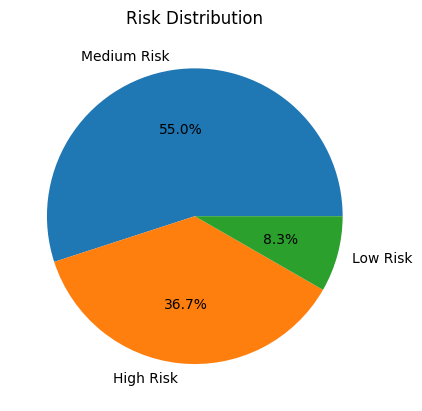

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
data["risk_level"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Risk Distribution")
plt.ylabel("")
plt.show()

In [ ]:
top5 = data.sort_values(by="risk_score", ascending=False).head(5)
display(top5)

,transaction_id,amount,transactions_per_day,location_risk,risk_score,risk_level,action,fraud_probability,priority_rank,alert
999,T1000,16945,13,High,100.0,High Risk,Block Transaction,100.0,23.5,ALERT
357,T0358,17888,14,High,100.0,High Risk,Block Transaction,100.0,23.5,ALERT
990,T0991,12289,13,High,100.0,High Risk,Block Transaction,100.0,23.5,ALERT
440,T0441,11745,14,High,100.0,High Risk,Block Transaction,100.0,23.5,ALERT
326,T0327,19582,12,High,100.0,High Risk,Block Transaction,100.0,23.5,ALERT


In [ ]:
print("Sample Output:")
display(data.head(10)) ##SAMPLE

Sample Output:


,transaction_id,amount,transactions_per_day,location_risk,risk_score,risk_level,action,fraud_probability,priority_rank,alert
0,T0001,13945,3,High,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
1,T0002,7753,13,High,83.33,High Risk,Block Transaction,83.33,197.0,ALERT
2,T0003,2601,5,Low,27.78,Low Risk,Allow Transaction,27.78,986.0,OK
3,T0004,17866,9,Medium,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
4,T0005,18271,6,Medium,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
5,T0006,2113,9,Medium,44.44,Medium Risk,Verify Transaction,44.44,874.5,OK
6,T0007,7515,3,Low,44.44,Medium Risk,Verify Transaction,44.44,874.5,OK
7,T0008,16495,2,Low,61.11,Medium Risk,Verify Transaction,61.11,638.5,OK
8,T0009,16677,8,Medium,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
9,T0010,10612,5,Low,61.11,Medium Risk,Verify Transaction,61.11,638.5,OK


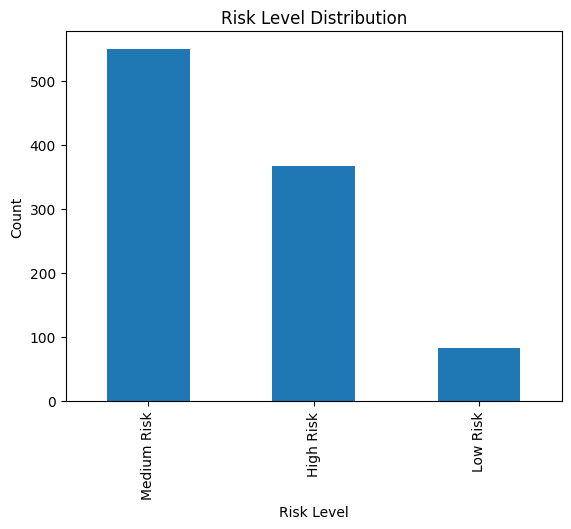

In [ ]:
plt.figure()
data["risk_level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

In [ ]:
high_risk = data[data["risk_level"] == "High Risk"]

print("High Risk Transactions:")
display(high_risk.head(10))

High Risk Transactions:


,transaction_id,amount,transactions_per_day,location_risk,risk_score,risk_level,action,fraud_probability,priority_rank,alert
0,T0001,13945,3,High,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
1,T0002,7753,13,High,83.33,High Risk,Block Transaction,83.33,197.0,ALERT
3,T0004,17866,9,Medium,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
4,T0005,18271,6,Medium,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
8,T0009,16677,8,Medium,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
15,T0016,17142,9,Medium,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
19,T0020,8854,12,High,83.33,High Risk,Block Transaction,83.33,197.0,ALERT
20,T0021,12638,4,High,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
25,T0026,11562,3,High,77.78,High Risk,Block Transaction,77.78,305.5,ALERT
30,T0031,12004,7,Medium,77.78,High Risk,Block Transaction,77.78,305.5,ALERT


In [ ]:
data.to_csv("intelliguard_output.csv", index=False)